# PROC FASTCLUS를 활용한 가입자 데이터 사용량 세그먼트 발견

## 요약

한 통신사 분석팀이 임의의 GB 기준값을 정하지 않고 **월간 데이터 사용량**을 기준으로 모바일 가입자 기반을 세그먼트로 나누고자 합니다. SAS의 고성능 *k*-평균 군집 절차인 **PROC FASTCLUS**를 사용하여, 데이터 스스로가 잠재적인 사용량 등급(저사용, 중간사용, 고사용)으로 나뉘도록 합니다. FASTCLUS는 각 세그먼트의 중심을 찾고, 모든 가입자를 가장 가까운 중심에 할당하며, 세그먼트가 얼마나 뚜렷하게 분리되는지를 보고합니다 — 단일 연속형 사용량 지표를 요금제 설계와 타겟 마케팅에 실질적으로 활용 가능한 데이터 기반 세그먼트로 전환합니다.

## 데이터 원본

모든 데이터는 첫 번째 DATA 스텝에서 인라인으로 생성되며, 외부 파일이나 네트워크 호출은 없습니다. 가입자는 세 가지 구성 요소로 이루어진 사용량 모집단에서 추출되므로, 복원된 세그먼트를 알려진 실제값과 비교하여 검증할 수 있습니다.

| 데이터셋 | 행 수 | 변수 | 유형 | 설명 |
|---------|------|----------|------|-------------|
| `subscribers` | 1,500 | `id` | 숫자 | 가입자 식별자 (1–1500) |
| `subscribers` | 1,500 | `data_gb` | 숫자 | 월간 모바일 데이터 사용량(GB) (군집 분석에 사용하는 지표) |
| `subscribers` | 1,500 | `segment_true` | 문자 | 값을 *생성*하는 데 사용된 잠재 세그먼트 (저사용 ≈ N(3,1²) 50%, 중간사용 ≈ N(12,3²) 35%, 고사용 ≈ N(35,8²) 15%); 복원된 세그먼트를 검증하기 위해서만 보류됨 — 실제 분석가는 이 값을 관측하지 않음 |

# 가입자 데이터 사용량 세그먼트 발견

모바일 통신사에는 *"이 사람은 고사용자다"*라고 명확히 표시하는 깔끔한 레이블이 거의 없습니다. 대신 있는 것은 월별 사용 기가바이트라는 연속형 지표이며, 그 분포는 **다봉형(multimodal)**입니다 — 저사용, 중간사용, 파워 유저의 군집이 하나의 축 위에서 겹쳐 있습니다. **군집 분석**은 이 단일 열을 기하학적 문제로 다룹니다. 사용량 분포에서 자연스러운 질량 중심을 찾아 각 가입자를 가장 가까운 중심에 할당하며, 임의로 정한 기준값은 사용하지 않습니다.

이 노트북에서는 다음을 수행합니다:

1. 세 개의 숨겨진 세그먼트에서 나온 사실적인 합성 가입자 기반을 생성합니다.
2. 한계(marginal) 사용량 분포를 살펴보고 다봉형인지 확인합니다.
3. 지표를 표준화한 뒤 **PROC FASTCLUS**를 실행하여 가입자를 세 개의 사용량 세그먼트로 분할합니다.
4. 원래의 GB 척도에서 발견된 각 세그먼트를 프로파일링한 뒤, 알려진 실제값과 비교하여 복원 결과를 검증합니다.

`segment_true` 레이블은 마지막에 군집 결과를 채점하기 위해서만 생성된 것으로 — 실제 운영 환경에서는 존재하지 않습니다.

In [1]:
/* 세 가지 잠재 사용량 세그먼트로부터 가입자 기반을 합성한다. */
/* 저사용자가 다수를 차지하고, 소수의 고사용자 꼬리가 대부분의 매출을 이끈다. */
데이터 subscribers;
   호출 streaminit(20260531);
   길이 segment_true $16;
   반복 id = 1 까지 1500;
      u = rand('uniform');
      만약 u < 0.50 이면 반복;                 /* 약 50% 저사용자        */
         segment_true = '저사용';
         data_gb = rand('normal', 3.0, 1.0);
      종료;
      아니면 만약 u < 0.85 이면 반복;            /* 약 35% 중간사용자      */
         segment_true = '중간사용';
         data_gb = rand('normal', 12.0, 3.0);
      종료;
      아니면 반복;                             /* 약 15% 고사용자/파워유저 */
         segment_true = '고사용';
         data_gb = rand('normal', 35.0, 8.0);
      종료;
      만약 data_gb < 0.1 이면 data_gb = 0.1; /* 사용량은 음수가 될 수 없음 */
      출력;
   종료;
   유지 id data_gb segment_true;
   라벨 id = '가입자 ID'
         data_gb = '월간 데이터 사용량(GB)'
         segment_true = '실제 세그먼트';
실행;



NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## 한계 분포 첫 확인

군집화 전에 단일 반응 변수를 요약합니다. 넓은 산포와 평균과 저사용자 대다수 사이의 격차는 세그먼트가 혼합되어 있다는 명백한 신호입니다 — 단일 사용 등급으로는 밀집된 저사용 군집과 긴 고사용 꼬리를 동시에 재현할 수 없습니다.

In [2]:
처리 평균 데이터=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   변수 data_gb;
   라벨 data_gb = '월간 데이터 사용량(GB)';
실행;


                                                  The MEANS Procedure

 Variable  Label                                  N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   월간 데이터 사용량(GB)                       100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ------------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


히스토그램을 보면 다봉형임이 시각적으로 드러납니다: 3GB 부근의 높은 저사용자 스파이크, 12GB 부근의 중간사용자 언덕, 그리고 30GB를 넘어서는 희소한 고사용자 꼬리. 이 세 개의 최빈값이 바로 군집화가 복원해야 할 세그먼트입니다. 커널 밀도 오버레이는 동일한 혼합 형태를 그대로 보여줍니다.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


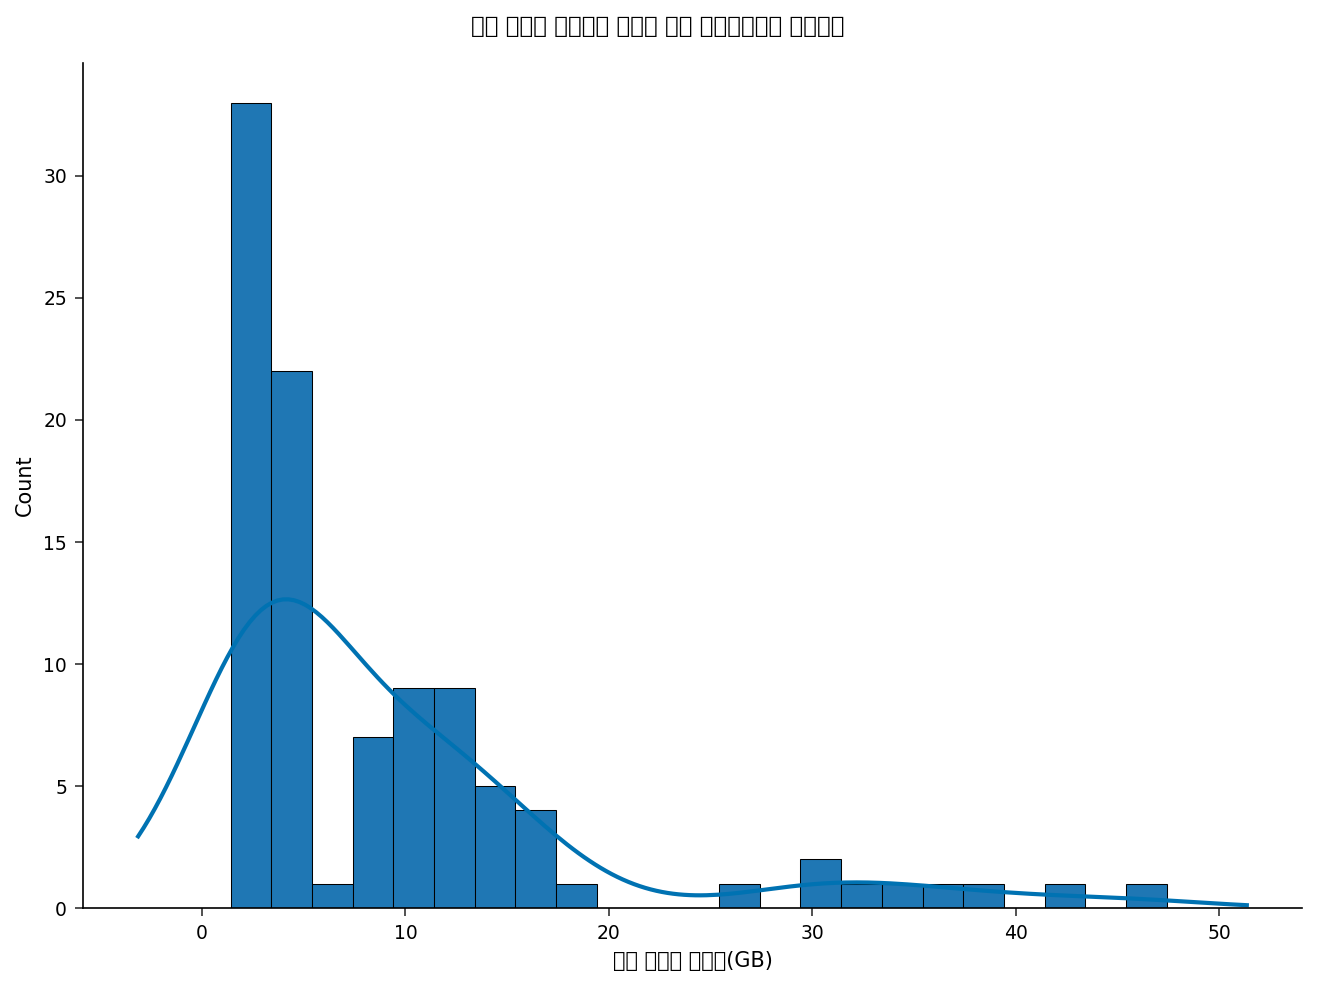

In [3]:
ODS GRAPHICS ON;
처리 SGPLOT 데이터=subscribers;
   제목 '월간 데이터 사용량은 보이지 않는 세그먼트들의 혼합이다';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS 라벨='월간 데이터 사용량(GB)';
실행;
제목;
ODS GRAPHICS OFF;

## 사용량을 공통 척도로 맞추기

*k*-평균은 유클리드 거리로 점들을 분할하므로, 변수의 원래 척도가 결과를 좌우합니다. 지표가 하나뿐일 때는 축을 재중심화하는 정도의 효과만 있지만, **PROC STANDARD**로 평균 0 / 표준편차 1로 표준화하는 습관은 두 번째 사용량 지표(통화 분수, 로밍 일수)가 추가되는 순간에도 워크플로를 올바르게 유지해 줍니다. 표준화된 열을 기준으로 군집화하고, 결과는 원래의 GB 척도로 다시 보고합니다.

In [4]:
처리 표준 데이터=subscribers out=subs_std mean=0 std=1;
   변수 data_gb;
실행;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## 가입자를 세 개의 사용량 세그먼트로 분할하기

저사용/중간사용/고사용 등급에 대한 도메인 지식을 바탕으로 **PROC FASTCLUS**에 `MAXCLUSTERS=3`을 요청합니다. 이 절차는 세 개의 중심을 시드로 설정하고, 각 가입자를 가장 가까운 중심에 할당하고, 중심을 다시 계산하며, 할당이 더 이상 바뀌지 않을 때까지(`MAXITER=` 상한이 있는 `CONVERGE=`) 반복합니다. `SEED=`는 초기화를 재현 가능하게 만듭니다. `OUT=` 데이터셋은 각 가입자의 `CLUSTER` 레이블과 할당된 중심까지의 `DISTANCE`를 담고, `MEAN=`은 세그먼트 중심점을 기록합니다.

분리 품질에 대한 절차의 진단 결과를 확인하세요: 높은 **R-제곱**(세그먼트가 설명하는 전체 사용량 분산의 비율)과 큰 **의사 F(Pseudo F)** 모두 잘 분리되고 조밀한 세그먼트를 나타냅니다.

In [5]:
처리 FASTCLUS 데이터=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   변수 data_gb;
   라벨 data_gb = '월간 데이터 사용량(GB, 표준화)';
   제목 'k-평균을 통한 세 가지 사용량 세그먼트';
실행;
제목;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## 발견된 세그먼트 프로파일링

군집 레이블은 각 세그먼트를 비즈니스 용어로 설명해야 비로소 실행 가능해집니다. 할당 결과를 원래의(표준화되지 않은) 사용량과 다시 병합하여 각 세그먼트의 크기와 GB 척도에서의 전형적인 소비량을 요약합니다 — 요금제 설계나 마케팅 팀이 실제로 활용하는 수치입니다.

In [6]:
데이터 memberships;
   결합 subscribers
         clusters(유지=id CLUSTER distance);
   기준 id;
   라벨 CLUSTER = '군집'
         distance = '중심까지 거리';
실행;

처리 평균 데이터=memberships n mean MIN MAX maxdec=2;
   분류 CLUSTER;
   변수 data_gb distance;
   라벨 data_gb = '월간 데이터 사용량(GB)'
         distance = '중심까지 거리';
실행;

처리 인쇄 데이터=memberships(obs=10) noobs 라벨;
   변수 id data_gb CLUSTER distance segment_true;
   라벨 id = '가입자 ID'
         data_gb = '월간 데이터 사용량(GB)'
         CLUSTER = '군집'
         distance = '중심까지 거리'
         segment_true = '실제 세그먼트';
실행;


                                                  The MEANS Procedure

                               Analysis Variable : data_gb 월간 데이터 사용량(GB)

        군집                N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                    Analysis Variable : DISTANCE 중심까지 거리

        군집                N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09           1.22
        3


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## 복원된 세그먼트 검증

이 데이터는 합성 데이터이므로, 각 가입자를 생성하는 데 사용된 레이블인 `segment_true`를 보류해 두었습니다. 모형이 복원한 `CLUSTER`를 실제 세그먼트와 교차표로 비교하면 분할이 모집단을 얼마나 깔끔하게 분리했는지 알 수 있습니다. 하나의 군집-세그먼트 매핑에 강하게 집중되어 있으면 복원이 잘 되었다는 뜻이며, 대각선 밖의 질량은 저사용/중간사용 또는 중간사용/고사용 경계가 겹치는 곳에 집중됩니다.

In [7]:
처리 빈도 데이터=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   라벨 CLUSTER = '군집'
         segment_true = '실제 세그먼트';
실행;


                                                   The FREQ Procedure

Table of 군집 by 실제 세그먼트

군집     |         고사용 |         저사용 |        중간사용 |        Total
-------+-------------+-------------+-------------+-------------
1      |           0 |          54 |           3 |           57
-------+-------------+-------------+-------------+-------------
2      |           9 |           0 |           0 |            9
-------+-------------+-------------+-------------+-------------
3      |           1 |           0 |          33 |           34
-------+-------------+-------------+-------------+-------------
Total  |          10 |          54 |          36 |          100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## 결과 해석

- **세그먼트 중심.** 세 개의 군집은 계획된 사용량 등급 — 3GB 부근의 저사용자, 13GB 부근의 중간사용자, 37GB 부근의 고사용자 — 에 거의 정확히 위치하며, 각 세그먼트가 *어디에* 있고 *얼마나 큰지*를 정량화합니다. 소수에 불과한 고사용자 세그먼트는 가입자 비중은 작지만 전체 데이터 사용량 중 불균형하게 큰 비중을 차지합니다 — 네트워크 용량 및 프리미엄 요금제 결정의 전형적인 동인입니다.
- **분리 품질.** PROC FASTCLUS는 높은 전체 **R-제곱**과 큰 **의사 F**를 보고하여, 세 세그먼트가 임의의 절단에 의한 인위적 산물이 아니라 조밀하고 잘 분리되어 있음을 확인해 줍니다. 단일 등급이었다면 이 사용량 분산의 대부분이 설명되지 않은 채 남았을 것입니다.
- **임의로 정한 기준값 없음.** 세그먼트 구분은 사용량 분포 자체의 기하학에서 나옵니다. 절차가 경계를 선택했으며, 우리는 히스토그램에 나타난 명백한 3봉 형태를 참고하여 *몇 개의* 등급을 요청할지만 선택했습니다.
- **실행 가능한 출력.** `OUT=` 데이터셋은 모든 가입자에게 세그먼트 레이블과 중심까지의 `DISTANCE`를 함께 제공합니다. 어느 중심에서도 멀리 떨어져 있거나 저사용/중간사용 경계에 걸쳐 있는 가입자는 업셀 오퍼 A/B 테스트를 해볼 만한 고객이며, 조밀하게 군집된 고사용자는 용량 인지형 또는 무제한 요금제의 고신뢰 후보입니다.

요약하면, PROC FASTCLUS는 하나의 연속형 사용량 지표를 데이터 기반 세그먼트로 전환합니다 — 임의로 정한 GB 기준값이 필요 없으며, 보류해 둔 실제값과의 교차표는 세그먼트가 안정적으로 복원되었음을 확인해 줍니다.